STAligner test


In [10]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import squidpy as sq
import pandas as pd
import numpy as np
import paste as pst
import ot

In [11]:
ot.backend.get_backend_list()

In [12]:
sliceA = sc.read_h5ad("data/151671_preprocessed.h5")
sliceB = sc.read_h5ad("data/151672_preprocessed.h5")

In [13]:
sliceB

AnnData object with n_obs × n_vars = 3888 × 10609
    obs: 'in_tissue', 'array_row', 'array_col', 'imagerow', 'imagecol', 'sum_umi', 'sum_gene', 'subject', 'position', 'replicate', 'discard', 'cell_count', 'layer_guess', 'layer_guess_reordered', 'layer_guess_reordered_short', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'layer_guess_reordered_colors'
    obsm: 'spatial'

In [14]:
sliceA.obsm['spatial'] = sliceA.obsm['spatial'].astype("int32")
sliceB.obsm['spatial'] = sliceB.obsm['spatial'].astype("int32")

In [16]:
pi_AB = pst.pairwise_align(sliceA, sliceB, numItermax = 1000)

Using selected backend cpu. If you want to use gpu, set use_gpu = True.


/Users/amanuky/miniforge3/envs/paste/lib/python3.9/site-packages/ot/lp/__init__.py:346: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


In [17]:
pis = [pi_AB]
slices = [sliceA, sliceB]
new_slices = pst.stack_slices_pairwise(slices, pis)

In [18]:
new_slices[0].write_h5ad("results/151671adata_aligned.h5ad")
new_slices[1].write_h5ad("results/151672adata_aligned.h5ad")

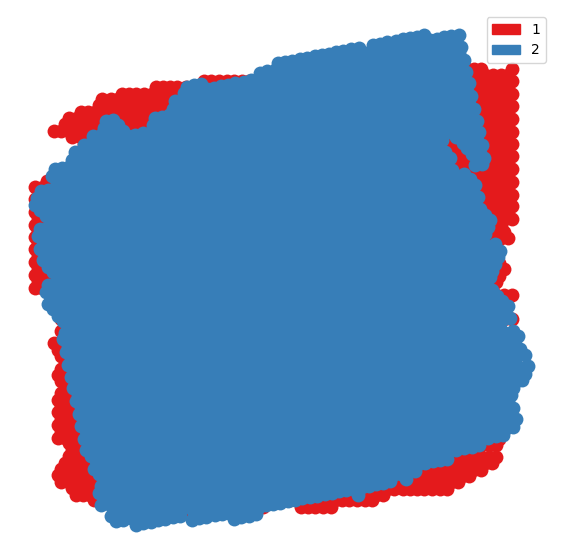

In [20]:
slice_colors = ['#e41a1c','#377eb8']

plt.figure(figsize=(7,7))
for i in range(2):
    pst.plot_slice(new_slices[i],slice_colors[i],s=400)
plt.legend(handles=[mpatches.Patch(color=slice_colors[0], label='1'),mpatches.Patch(color=slice_colors[1], label='2')])
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()